In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#loading

In [ ]:
df = pd.read_excel("dataset.xlsx")

df.head()


,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         648 non-null    int64  
 1   Year               648 non-null    int64  
 2   Country            648 non-null    object 
 3   Region             648 non-null    object 
 4   Artist             648 non-null    object 
 5   Song               648 non-null    object 
 6   Artist.gender      226 non-null    object 
 7   Group.Solo         226 non-null    object 
 8   Place              648 non-null    int64  
 9   Points             648 non-null    int64  
 10  Home.Away.Country  648 non-null    object 
 11  Home.Away.Region   648 non-null    object 
 12  Is.Final           648 non-null    int64  
 13  Semi.Final.Number  281 non-null    float64
 14  Song.In.English    648 non-null    int64  
 15  Song.Quality       648 non-null    float64
 16  Normalized.Points  648 non

In [ ]:
df.describe()

,Unnamed: 0,Year,Place,Points,Is.Final,Semi.Final.Number,Song.In.English,Song.Quality,Normalized.Points,energy,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
count,648.000000,648.000000,648.000000,648.000000,648.000000,281.000000,648.000000,648.000000,648.000000,482.000000,...,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,480.000000,304.000000
mean,324.500000,2006.543210,11.858025,77.783951,0.566358,1.327402,0.728395,2.636140,0.044753,0.725833,...,0.571246,113.905349,0.056576,5.782158,0.201399,3.900415,0.580913,-6.516718,0.521286,5.406843
std,187.205769,4.016733,6.795186,63.301464,0.495960,0.470103,0.445131,2.089733,0.034887,0.186675,...,0.136131,24.958535,0.050582,3.453922,0.172561,0.485164,0.493922,2.358372,0.236548,0.288879
min,1.000000,1998.000000,1.000000,0.000000,0.000000,1.000000,0.000000,-0.424200,0.000000,0.064730,...,0.183719,64.971000,0.023994,0.000000,0.026513,1.000000,0.000000,-21.878000,0.017786,4.375630
25%,162.750000,2004.000000,6.000000,30.000000,0.000000,1.000000,0.000000,1.017664,0.017946,0.607444,...,0.489436,91.968500,0.032869,2.250000,0.090076,4.000000,0.000000,-7.735000,0.328387,5.251099
50%,324.500000,2007.000000,12.000000,62.000000,1.000000,1.000000,1.000000,2.054728,0.035151,0.759969,...,0.574584,121.357500,0.041742,6.000000,0.136240,4.000000,1.000000,-6.169500,0.525902,5.464790
75%,486.250000,2010.000000,17.000000,110.000000,1.000000,2.000000,1.000000,3.864811,0.065451,0.881004,...,0.669654,130.163000,0.060256,9.000000,0.277933,4.000000,1.000000,-4.894000,0.723856,5.579380
max,648.000000,2012.000000,28.000000,387.000000,1.000000,2.000000,1.000000,9.795199,0.158867,0.999169,...,0.894179,211.985000,0.505107,11.000000,0.987510,7.000000,1.000000,-2.352000,0.971989,6.148232


In [ ]:
df.shape

(648, 30)

In [ ]:
df.dtypes

,0
Unnamed: 0,int64
Year,int64
Country,object
Region,object
Artist,object
Song,object
Artist.gender,object
Group.Solo,object
Place,int64
Points,int64


In [ ]:
#data analysis

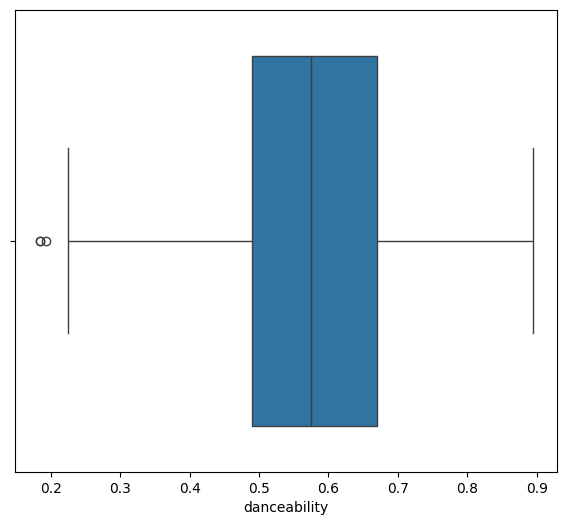

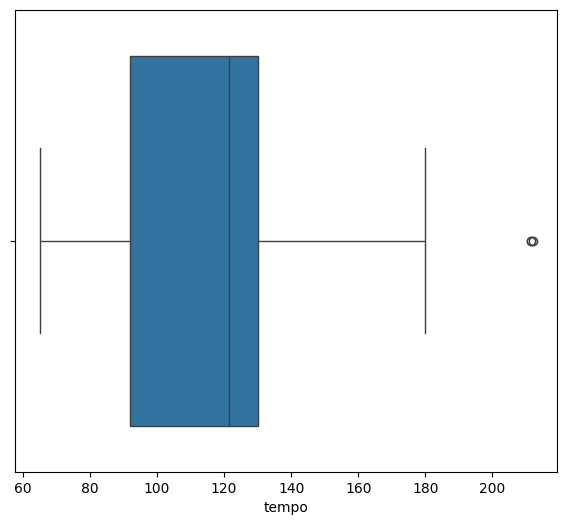

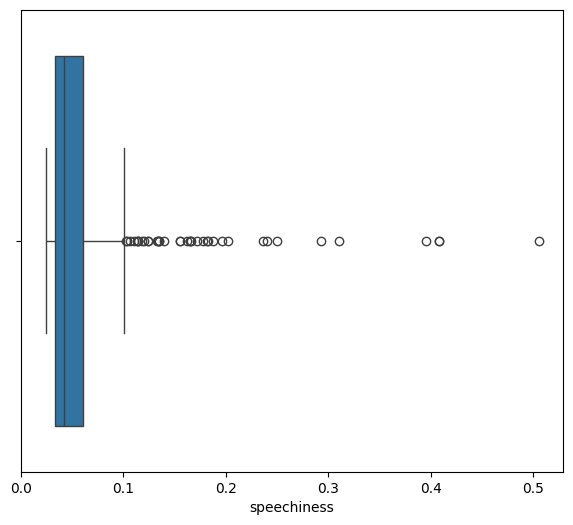

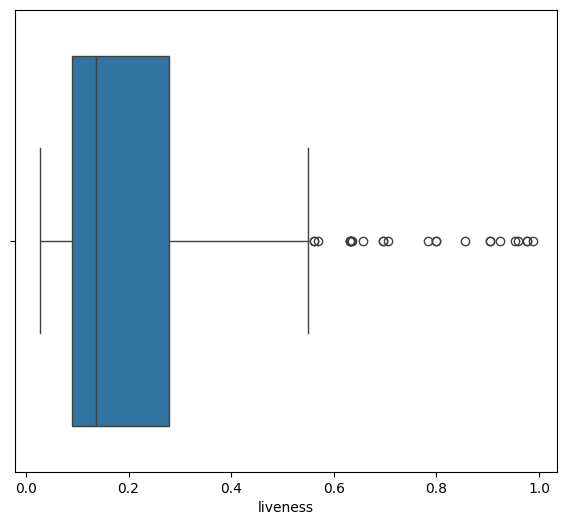

In [ ]:
#outliers checking
df.head(2)
for col in['danceability','tempo','speechiness','liveness']:
  plt.figure(figsize=(7,6))
  sns.boxplot(x=df[col])
  plt.show()

In [ ]:
from pandas.core import series
def cap_outliers(series):
  Q1=series.quantile(0.25)
  Q3=series.quantile(0.75)
  IQR=Q3-Q1

  #BOUND
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  #CAAPPING
  series=np.where(series<lower_bound,lower_bound,series)
  series=np.where(series>upper_bound,upper_bound,series)
  return series

In [ ]:
df['danceability']=cap_outliers(df['danceability'])
df['tempo']=cap_outliers(df['tempo'])
df['liveness']=cap_outliers(df['liveness'])
df['speechiness']=cap_outliers(df['speechiness'])

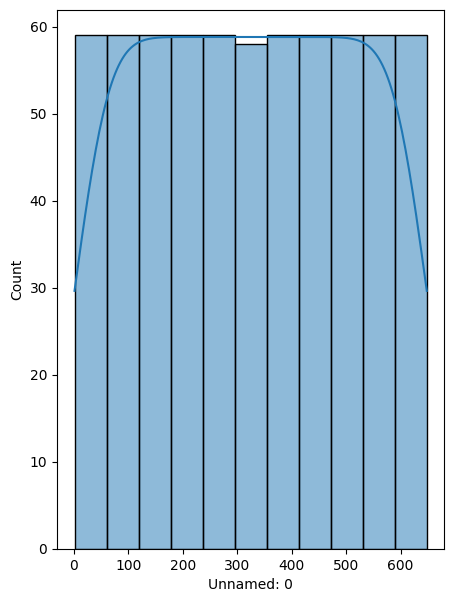

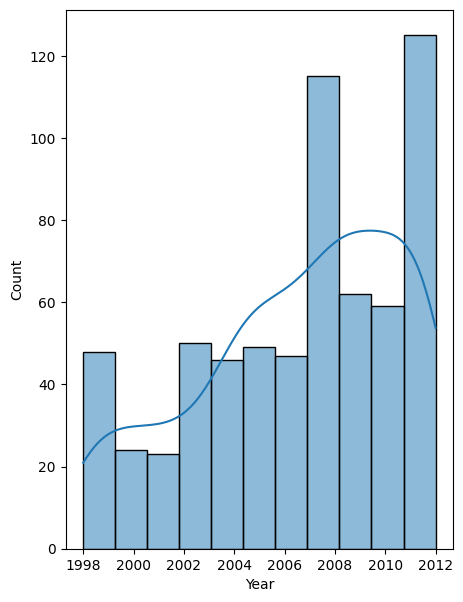

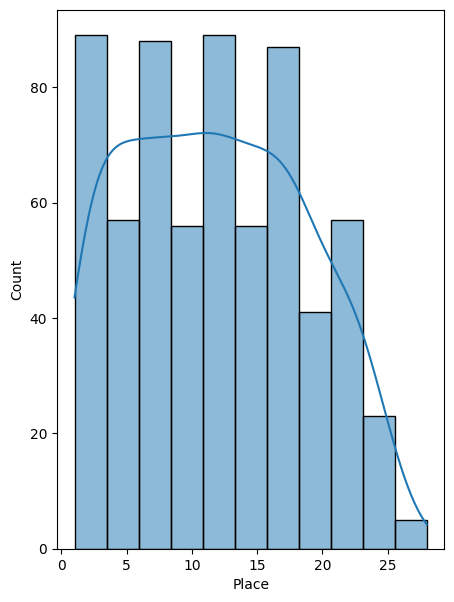

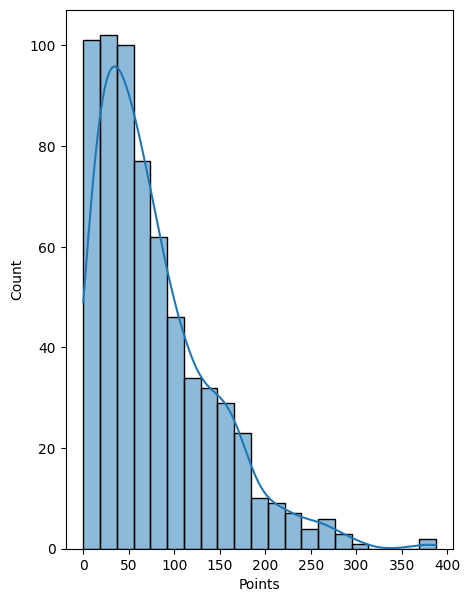

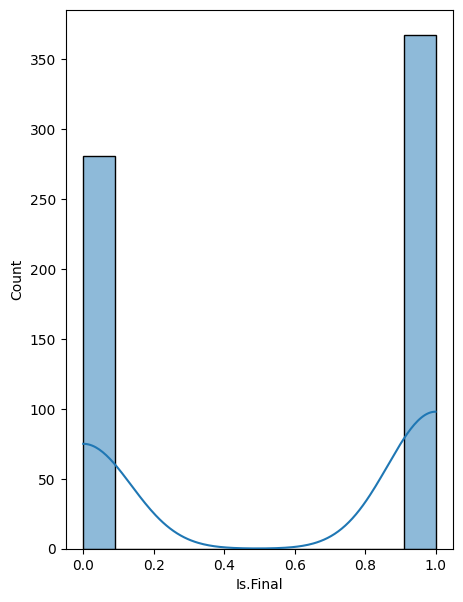

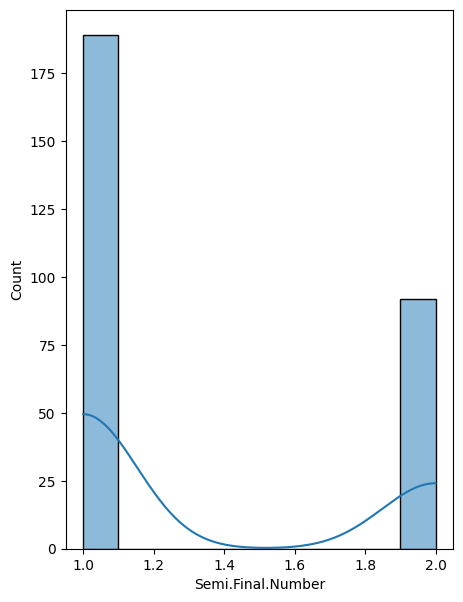

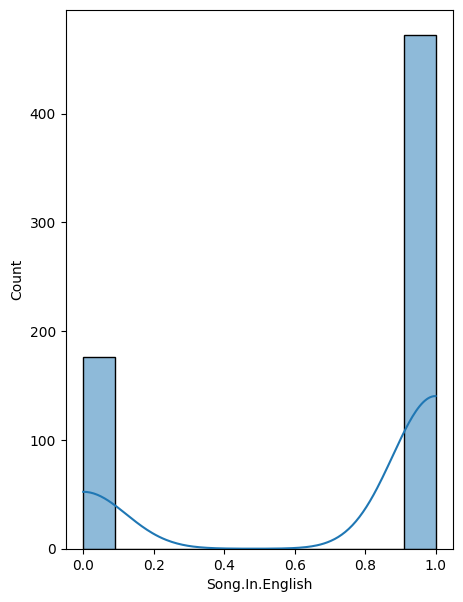

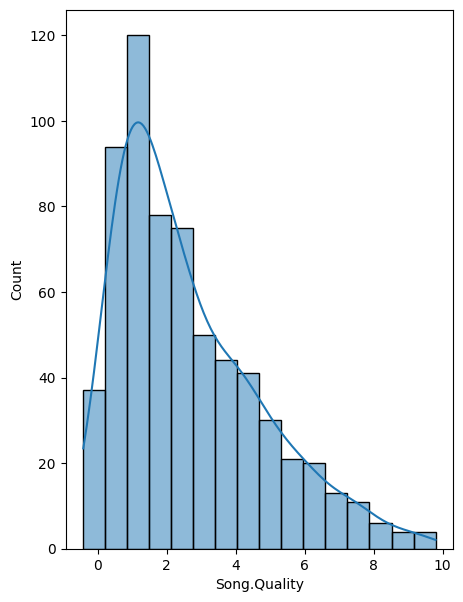

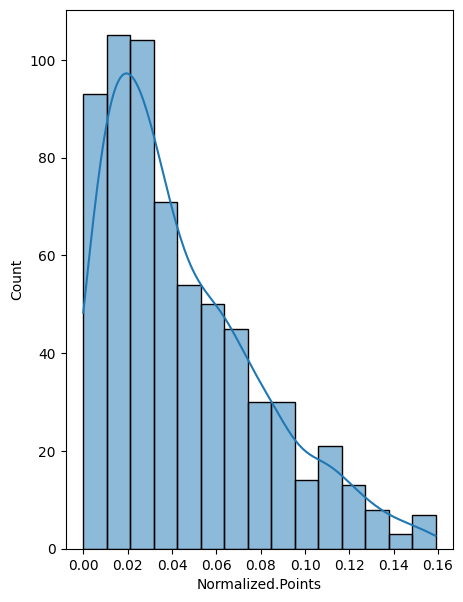

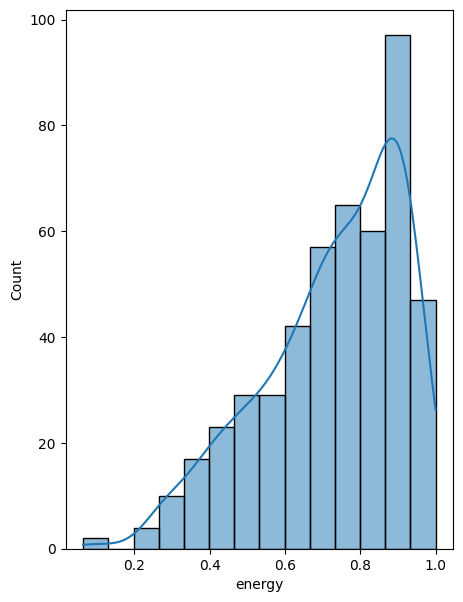

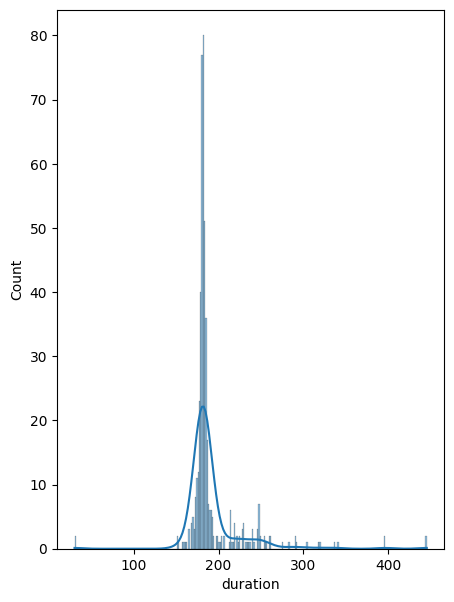

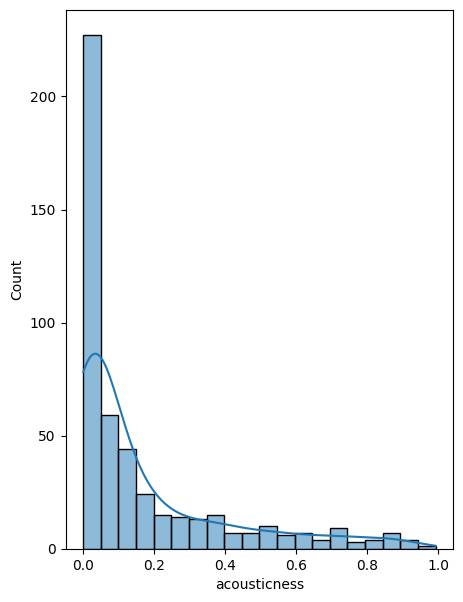

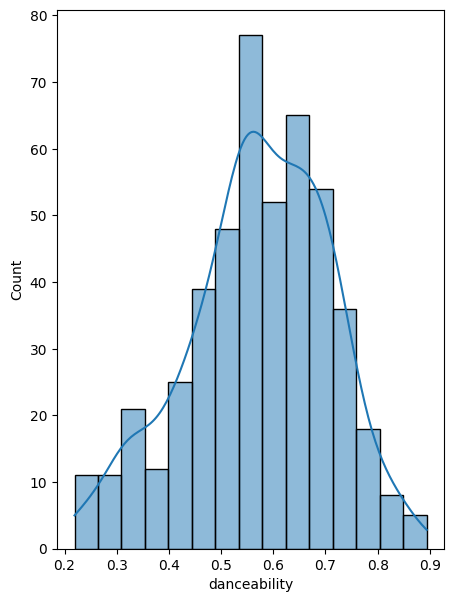

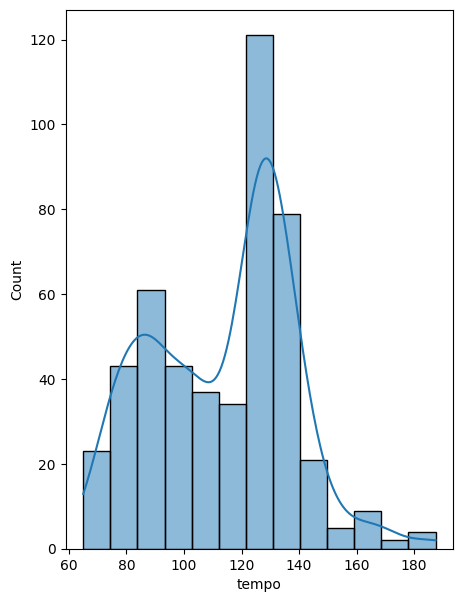

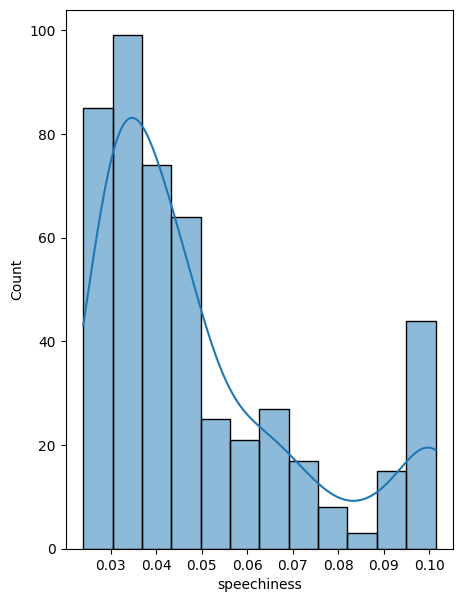

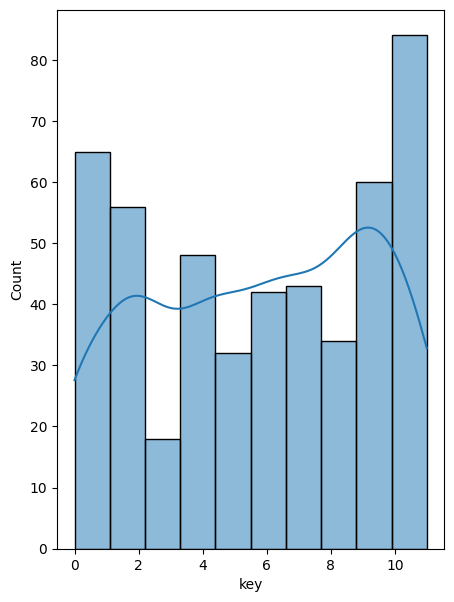

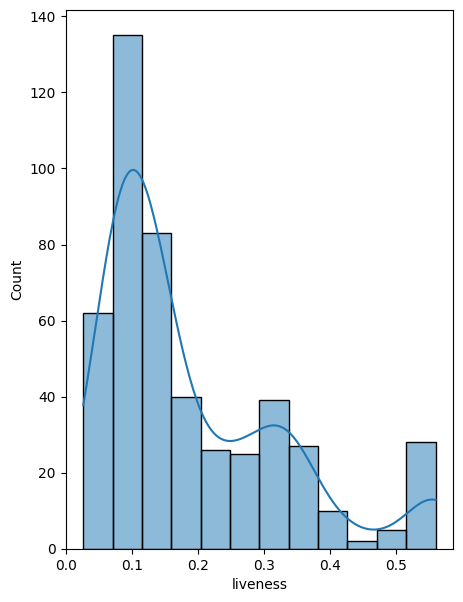

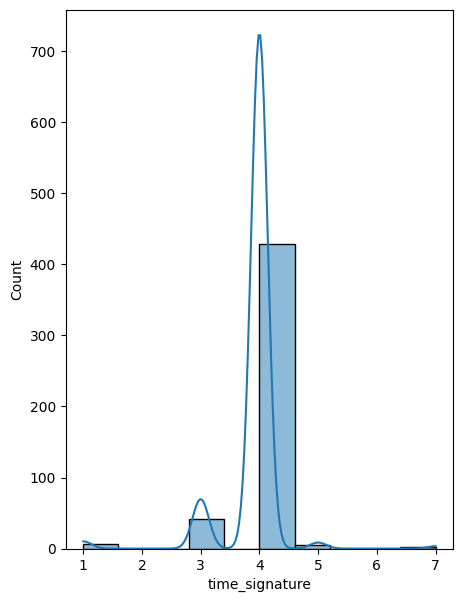

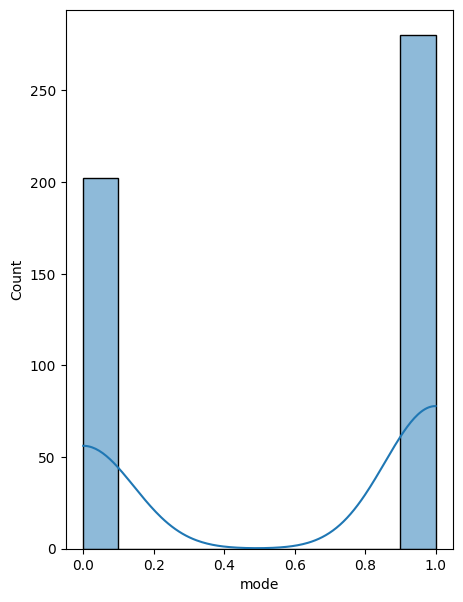

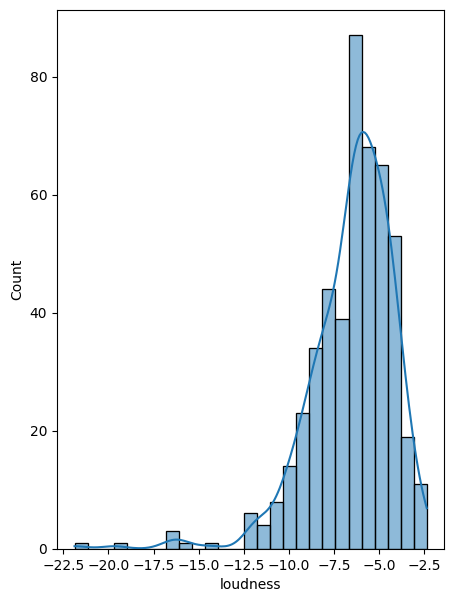

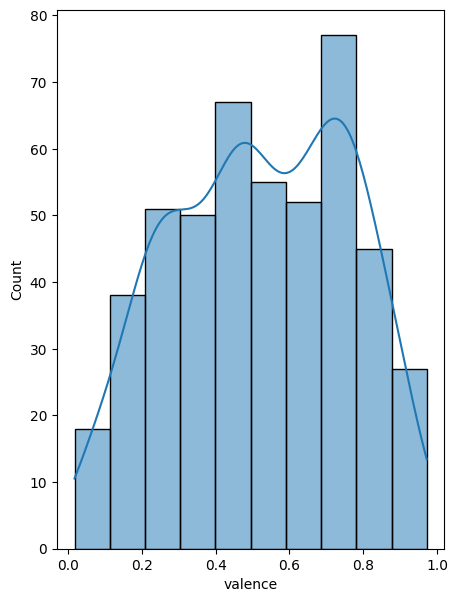

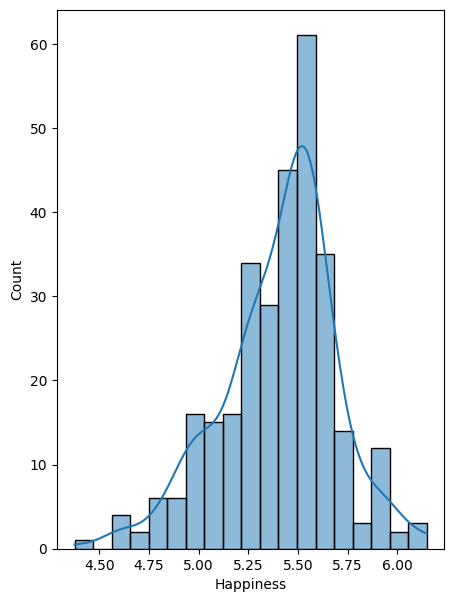

In [ ]:
#null values handling
num_cols=num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
  plt.figure(figsize=(5,7))
  sns.histplot(df[col],kde=True)
  plt.show()

In [ ]:
df.dtypes

,0
Unnamed: 0,int64
Year,int64
Country,object
Region,object
Artist,object
Song,object
Artist.gender,object
Group.Solo,object
Place,int64
Points,int64


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

#categorical column with mode
cat_cols = ['Artist.gender','Group.Solo','Song.In.English']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,0
Group.Solo,0
Place,0
Points,0


- for numeric column i used median imputation for dancebility and speecheless. meadian is less affected by the outliers.
- for categorical columns missing values replaced by mode,songSong.In.English,and artis gender colum were replaced by mode.


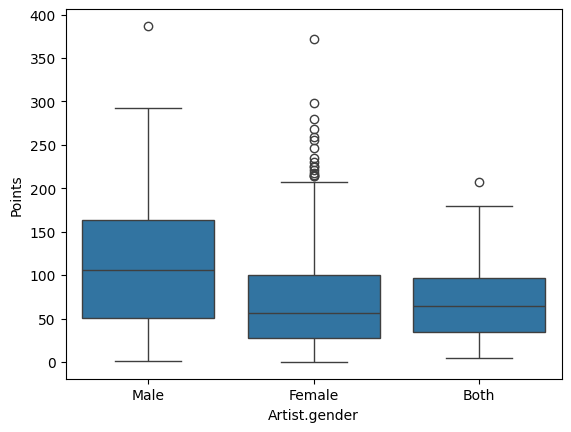

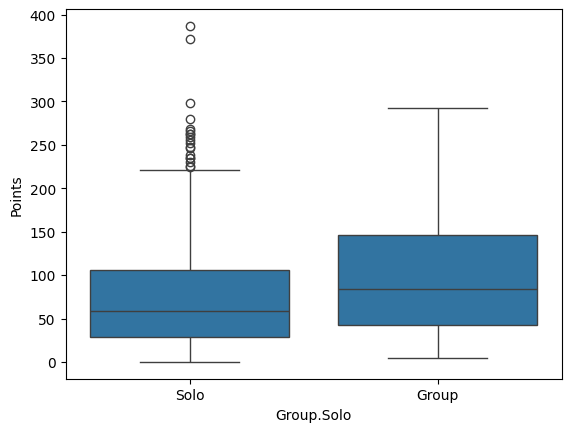

In [ ]:
#encoding
#relationship between the target variables
#categorical vs num
sns.boxplot(x='Artist.gender', y='Points',data=df)
plt.show()

sns.boxplot(x='Group.Solo', y='Points', data=df)
plt.show()

In [ ]:
df.head(3)

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.559719,4.0,1.0,-8.655,0.292870,5.069762


In [ ]:
#selecting the relevent features
# Your features will be columns like Year, Artist.gender, Group.Solo,
#Song.In.English, and the various audio features (energy, danceability,
df = df.drop(columns=['Unnamed: 0','Country','Region','Artist','Song','Place','Normalized.Points','Home.Away.Country','Home.Away.Region','Is.Final','Semi.Final.Number'])

#droping the  columns that has no predictive powers

In [ ]:
features = ['Year','Artist.gender','Group.Solo','Song.In.English','energy','danceability','tempo','loudness']


In [ ]:
features

['Year',
 'Artist.gender',
 'Group.Solo',
 'Song.In.English',
 'energy',
 'danceability',
 'tempo',
 'loudness']

In [ ]:
#eda and modeling
#split the target columns and feature column
x=df[features]
y=df['Points']

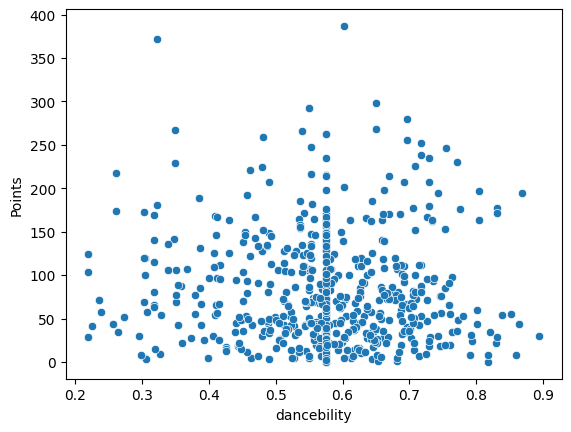

In [ ]:
sns.scatterplot(x=df['danceability'],y=df['Points'])
plt.xlabel('dancebility')
plt.ylabel('Points')
plt.show()

from scatterplot we can see than ,whenever the dancebility increases points also increases.so it indicates a strong postive realtionship.when a danceble song is increase the points that we recieve also incerasing.
- hypothesis
  - when danceable songs are more engaging the audience, it may contribute higher scores in contest.

In [ ]:
features

['Year',
 'Artist.gender',
 'Group.Solo',
 'Song.In.English',
 'energy',
 'danceability',
 'tempo',
 'loudness']

In [ ]:
x.dtypes

,0
Year,int64
Artist.gender,object
Group.Solo,object
Song.In.English,int64
energy,float64
danceability,float64
tempo,float64
loudness,float64


In [ ]:
x['Artist.gender']

,Artist.gender
0,Male
1,Female
2,Female
3,Female
4,Both
...,...
643,Female
644,Female
645,Female
646,Female


In [ ]:
x['Group.Solo']

,Group.Solo
0,Solo
1,Group
2,Solo
3,Solo
4,Group
...,...
643,Solo
644,Solo
645,Solo
646,Solo


In [ ]:
x['Song.In.English']

,Song.In.English
0,1
1,1
2,0
3,1
4,0
...,...
643,0
644,1
645,0
646,1


In [ ]:
cat_col=['Artist.gender','Group.Solo','Song.In.English']
num_col=['Year','energy','danceability','tempo','loudness']

In [ ]:
from sklearn.preprocessing import OneHotEncoder
x = pd.get_dummies(x, columns=cat_col, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train[num_col] = scaler.fit_transform(x_train[num_col])
x_test[num_col] = scaler.transform(x_test[num_col])

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor()
model.fit(x_train,y_train)


GradientBoostingRegressor()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
metrics=pd.DataFrame({
    'MAE':[mean_absolute_error(y_test,y_pred)],
    'mse':[mean_squared_error(y_test,y_pred)],
    'r2':[r2_score(y_test,y_pred)]
})
metrics

,MAE,mse,r2
0,41.688199,3065.236809,0.304547


In [ ]:
from xgboost import XGBRegressor
xgr = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6
)
model.fit(x_train,y_train)

GradientBoostingRegressor()

In [ ]:
y_pred_xgr = model.predict(x_test)

In [ ]:
mae = mean_absolute_error(y_test,y_pred_xgr)
mae

41.647453688030666

In [ ]:
# r2 scores are very low after standarscaling outliers handling and cleaning

 mae=measures the average difference between the predicted values and the actual values.estimate of how accurate the model is when predicting the success of a song.

In [ ]:
features

['Year',
 'Artist.gender',
 'Group.Solo',
 'Song.In.English',
 'energy',
 'danceability',
 'tempo',
 'loudness']

In [ ]:
import pickle

with open("eurovision_model.pkl","wb") as f:
    pickle.dump(model,f)